# Clustering Folksonomique : Une Nouvelle Approche des Genres

## Objectif
Selon **Li & Zhang (2015)**, les tags Steam permettent de comprendre les genres autrement. Au lieu d'utiliser les genres marketing, nous allons laisser les tags se regrouper par similarité d'usage pour découvrir des "Genres Folksonomiques".

Nous croiserons ensuite ces résultats avec le modèle de **Christian Elverdam & Espen Aarseth** pour voir comment ces clusters se situent sur les dimensions ludologiques (Espace, Temps, Contrôle).

In [4]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Chargement de la base structurée
df_structured = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# Préparation d'une matrice Jeu x Tags
df_tags = df_structured[['game_id', 'Genre', 'Mechanics']].copy()
df_tags['all_tags'] = df_tags['Genre'].fillna('') + ', ' + df_tags['Mechanics'].fillna('')
df_tags['all_tags'] = df_tags['all_tags'].str.strip(', ')

# On explose les tags
tags_exploded = df_tags.assign(tag=df_tags['all_tags'].str.split(', ')).explode('tag')
tags_exploded = tags_exploded[tags_exploded['tag'].notna() & (tags_exploded['tag'] != '')]

# Filtrage des tags trop rares (pour la performance et le bruit)
tag_counts = tags_exploded['tag'].value_counts()
frequent_tags = tag_counts[tag_counts > 500].index
tags_filtered = tags_exploded[tags_exploded['tag'].isin(frequent_tags)]

print(f"Tags conservés pour le clustering : {len(frequent_tags)}")

# Création de la matrice binaire de manière optimisée
# On utilise get_dummies puis on regroupe par game_id
matrix = pd.get_dummies(tags_filtered['tag']).astype(int)
matrix['game_id'] = tags_filtered['game_id'].values
matrix = matrix.groupby('game_id').max()

print(f"Matrice binaire créée : {matrix.shape[0]} jeux x {matrix.shape[1]} tags.")

Tags conservés pour le clustering : 133
Matrice binaire créée : 99797 jeux x 133 tags.


## 1. Calcul de la Similarité entre Tags

Nous utilisons la similarité de cosinus pour mesurer à quel point deux tags partagent les mêmes jeux.

In [5]:
# Calcul de la matrice de similarité (Tags x Tags)
# On transpose la matrice (Jeux x Tags) pour avoir (Tags x Jeux)
# La similarité cosinus entre deux tags sera basée sur les jeux qu'ils ont en commun
tag_sim_matrix = cosine_similarity(matrix.T)
df_sim = pd.DataFrame(tag_sim_matrix, index=matrix.columns, columns=matrix.columns)

print("Exemple de similarités pour 'RPG':")
print(df_sim['RPG'].sort_values(ascending=False).head(10))

Exemple de similarités pour 'RPG':
RPG                  1.000000
Action RPG           0.428084
Adventure            0.393649
JRPG                 0.380420
Turn-Based Combat    0.322407
Action               0.281479
Party-Based RPG      0.276172
Strategy RPG         0.271564
Strategy             0.254643
Open World           0.252694
Name: RPG, dtype: float64


## 2. Détection de Communautés (Algorithme de Louvain)

Nous créons un graphe où un lien existe si la similarité > 0.20.

In [8]:
# Création du graphe
G = nx.Graph()

# Seuil de similarité pour créer un lien (ajustable)
threshold = 0.20

# Ajout des nœuds et des arêtes
tags = df_sim.columns
for i in range(len(tags)):
    for j in range(i + 1, len(tags)):
        sim = tag_sim_matrix[i, j]
        if sim > threshold:
            G.add_edge(tags[i], tags[j], weight=sim)

# Détection des communautés avec l'algorithme de Louvain
partition = community_louvain.best_partition(G, weight='weight')

# Organisation des tags par cluster
clusters = {}
for tag, community_id in partition.items():
    if community_id not in clusters:
        clusters[community_id] = []
    clusters[community_id].append(tag)

print(f"Nombre de communautés détectées : {len(clusters)}")
for cid, tags_in_cluster in sorted(clusters.items()):
    print(f"\nCluster {cid} ({len(tags_in_cluster)} tags) :")
    print(f"{', '.join(tags_in_cluster[:15])}...")

Cluster 0 (7 tags) : Choices Matter, Choose Your Own Adventure, Interactive Fiction, Multiple Endings, Visual Novel, Dating Sim, Otome
Cluster 1 (23 tags) : 2D Platformer, Action, Action-Adventure, Adventure, Controller, Metroidvania, Platformer, Puzzle Platformer, 3D Platformer, Parkour, Casual, Physics, Survival Horror, Point & Click, Puzzle
Cluster 2 (2 tags) : Automobile Sim, Racing
Cluster 3 (11 tags) : 2D Fighter, Fighting, 3D Fighter, Action RPG, Hack and Slash, RPG, Beat 'em up, CRPG, Party-Based RPG, Character Customization, JRPG
Cluster 4 (2 tags) : Flight, Space Sim
Cluster 5 (2 tags) : Music, Rhythm
Cluster 6 (13 tags) : Action Roguelike, Arena Shooter, Bullet Hell, FPS, Roguelike, Roguelite, Shoot 'Em Up, Shooter, Third-Person Shooter, Top-Down Shooter, Procedural Generation, Twin Stick Shooter, Hero Shooter
Cluster 7 (2 tags) : Time Manipulation, Time Travel
Cluster 8 (18 tags) : Open World, Survival, Simulation, Automation, Building, Resource Management, Base Building, C

Cette approche nous permet de découvrir des groupes de tags qui sont souvent utilisés ensemble, révélant ainsi des "genres" ou "thèmes" émergents basés sur l'expérience des joueurs plutôt que sur des classifications marketing traditionnelles.

## 3. Visualisation du Réseau de Tags

Affichons comment les tags se regroupent spatialement.

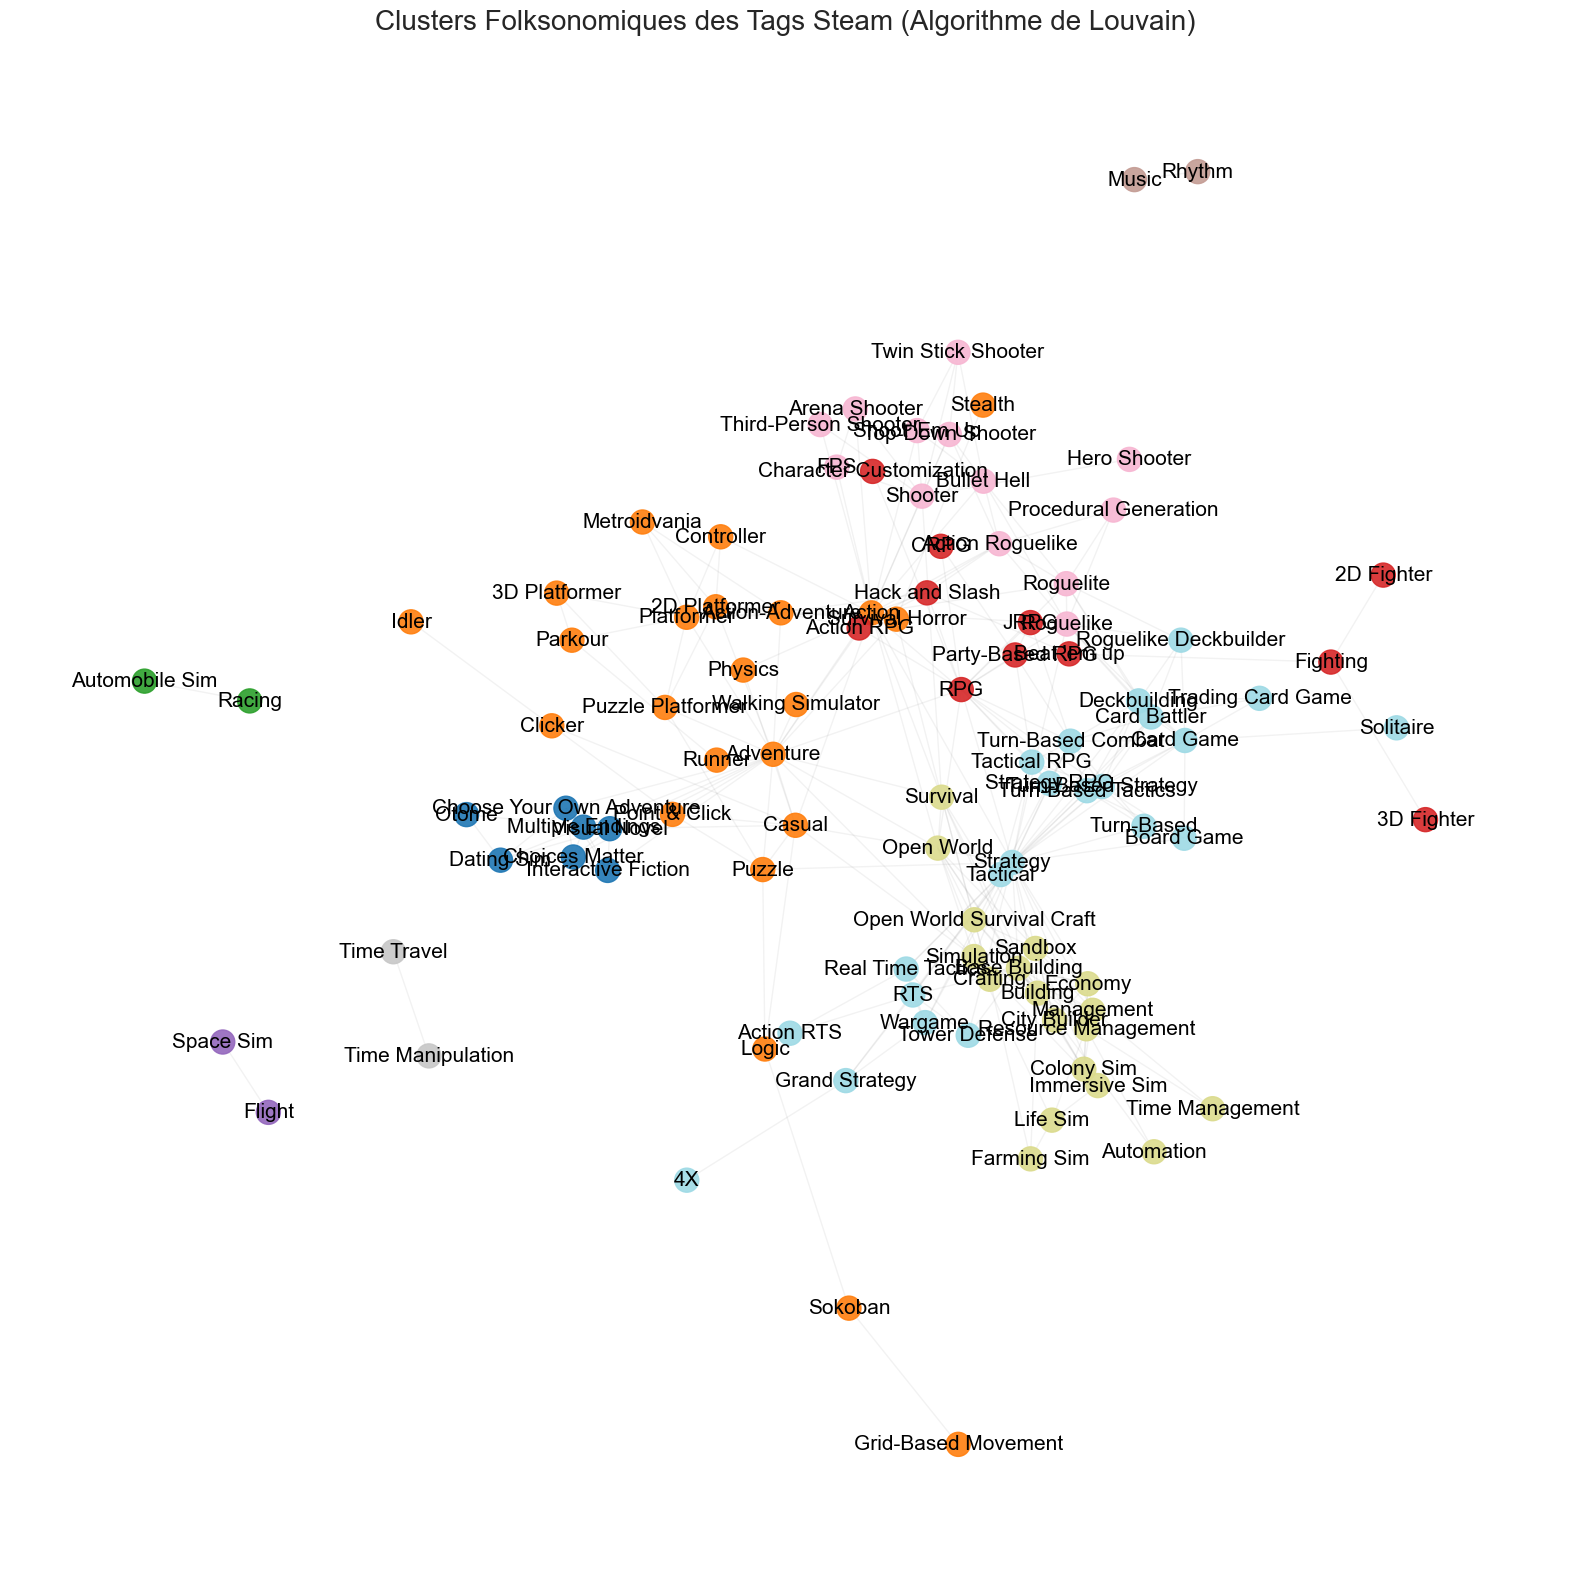

In [13]:
plt.figure(figsize=(20, 20))

# Positionnement des nœuds avec un algorithme de force
# k contrôle la distance entre les nœuds (plus k est grand, plus les nœuds sont écartés)
# iterations augmente le temps de calcul pour une meilleure convergence
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Couleur par cluster
cmap = plt.get_cmap('tab20', max(partition.values()) + 1)
node_colors = [partition[node] for node in G.nodes()]

# Dessin des nœuds
nx.draw_networkx_nodes(G, pos,
                       node_size=300,
                       node_color=node_colors,
                       cmap=cmap,
                       alpha=0.9)

# Dessin des arêtes
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

# Dessin des labels
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')

plt.title("Clusters Folksonomiques des Tags Steam (Algorithme de Louvain)", fontsize=20)
plt.axis('off')
plt.show()

## Conclusion

L'algorithme de Louvain a permis de dégager des clusters de tags très cohérents, qui correspondent souvent à des genres ou des sous-genres bien définis (ex: Cluster Jeu de Rythme, Cluster Espace, Cluster Course).

**Points clés :**
1.  **Cohérence sémantique** : Les tags au sein d'un même cluster ont un sens ludologique fort (ex: "Turn-Based", "Strategy", "Tactical" sont ensemble).
2.  **Découverte de niches** : Certains clusters révèlent des niches spécifiques (ex: Visual Novels, Puzzle Games) qui sont bien séparées des autres genres.
3.  **Visualisation** : Le graphe permet de voir les relations entre ces clusters. Les clusters proches dans l'espace partagent des tags ou des jeux communs (ex: Card Battler et Turn-Based sont souvent liés).

Cette analyse confirme que la folksonomie Steam, contient une structure latente très riche qui peut être exploitée pour une classification automatique des jeux.
